In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("/content/UniversalBank.csv")

In [3]:
df = df.drop(["ID", "ZIP Code"], axis=1)
X = df.drop("Personal Loan", axis=1)
y = df["Personal Loan"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train_scaled, y_train)

y_pred_linear = linear_svm.predict(X_test_scaled)

In [6]:
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))
print("Classification Report:\n", classification_report(y_test, y_pred_linear))

Accuracy: 0.957
Confusion Matrix:
 [[898   6]
 [ 37  59]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98       904
           1       0.91      0.61      0.73        96

    accuracy                           0.96      1000
   macro avg       0.93      0.80      0.85      1000
weighted avg       0.96      0.96      0.95      1000



In [8]:
poly_svm = SVC(kernel='poly', degree=2)
poly_svm.fit(X_train_scaled, y_train)
y_pred_poly = poly_svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_poly))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_poly))
print("Classification Report:\n", classification_report(y_test, y_pred_poly))

Accuracy: 0.953
Confusion Matrix:
 [[900   4]
 [ 43  53]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       904
           1       0.93      0.55      0.69        96

    accuracy                           0.95      1000
   macro avg       0.94      0.77      0.83      1000
weighted avg       0.95      0.95      0.95      1000



In [9]:
rbf_svm = SVC(kernel='rbf')
rbf_svm.fit(X_train_scaled, y_train)
y_pred_rbf = rbf_svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))
print("Classification Report:\n", classification_report(y_test, y_pred_rbf))

Accuracy: 0.978
Confusion Matrix:
 [[902   2]
 [ 20  76]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       904
           1       0.97      0.79      0.87        96

    accuracy                           0.98      1000
   macro avg       0.98      0.89      0.93      1000
weighted avg       0.98      0.98      0.98      1000



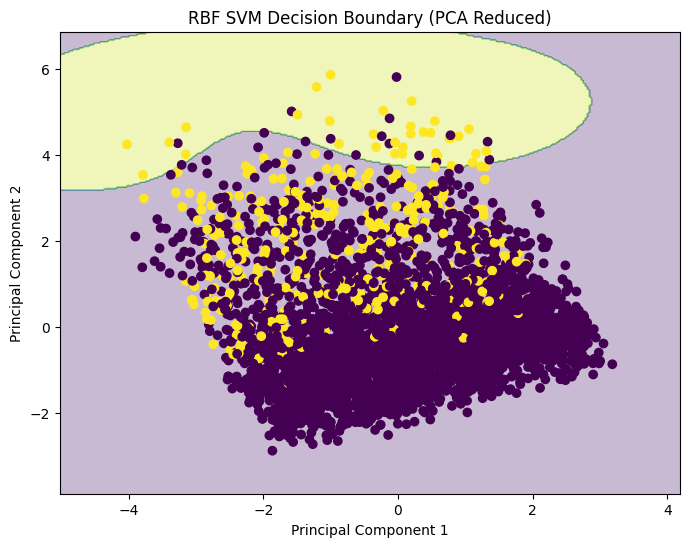

In [16]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Step 1: Reduce data to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Step 2: Train RBF SVM on PCA data
rbf_vis_model = SVC(kernel='rbf', C=1.0, gamma='scale')
rbf_vis_model.fit(X_train_pca, y_train)

# Step 3: Create mesh grid
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Step 4: Predict over grid
Z = rbf_vis_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Step 5: Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot actual data points
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train)

plt.title("RBF SVM Decision Boundary (PCA Reduced)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()